# Metadata feature importance

This notebook reproduces the safe-metadata feature-importance figure used for the presentation. It fits the same logistic-regression baseline as `03_metadata_baseline.ipynb`, extracts the one-hot feature coefficients, and saves a presentation-ready PNG plus the coefficient table.

In [1]:
4

4

In [2]:
from pathlib import Path
import re

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnnotationBbox, HPacker, TextArea
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

print('matplotlib', matplotlib.__version__)

matplotlib 3.10.8


In [3]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'src' else Path.cwd()
DATA_PATH = PROJECT_ROOT / 'data' / 'audited_metadata_with_split.csv'
OUT_DIR = PROJECT_ROOT / 'outputs'
OUT_DIR.mkdir(exist_ok=True)

SAFE_METADATA_FEATURES = [
    'Freshwater body type',
    'What is the main land use within 50m?',
    'What is the main bank vegetation? (select all that apply)',
    'Is there any of the following on the water surface?',
    'Estimate the water colour',
]

TARGET = 'binary_label'
ACCEPTABLE_COLOR = '#44a948'
UNACCEPTABLE_COLOR = '#c8322b'
TEXT_COLOR = '#263238'
GRID_COLOR = '#d9e1df'

In [4]:
df = pd.read_csv(DATA_PATH, low_memory=False)
df[TARGET] = df[TARGET].astype(int)
train_df = df[df['split'].eq('train')].copy()

print(f'Training rows: {len(train_df):,}')
print(train_df[TARGET].value_counts().sort_index().rename(index={0: 'Acceptable', 1: 'Unacceptable'}))

Training rows: 7,200
binary_label
Acceptable      2617
Unacceptable    4583
Name: count, dtype: int64


In [5]:
metadata_model = Pipeline([
    ('preprocess', ColumnTransformer([
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), SAFE_METADATA_FEATURES),
    ])),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced')),
])

metadata_model.fit(train_df[SAFE_METADATA_FEATURES], train_df[TARGET])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse ma

In [6]:
onehot = metadata_model.named_steps['preprocess'].named_transformers_['cat'].named_steps['onehot']
coef_df = pd.DataFrame({
    'feature': onehot.get_feature_names_out(SAFE_METADATA_FEATURES),
    'coefficient': metadata_model.named_steps['model'].coef_[0],
})

coef_df.head()

,feature,coefficient
0,Freshwater body type_Canal,-0.257217
1,Freshwater body type_Ditch,0.810623
2,Freshwater body type_Lake,-0.901194
3,Freshwater body type_Other,0.102851
4,Freshwater body type_Pond,-0.828511


In [7]:
def split_feature(full_name):
    for base in sorted(SAFE_METADATA_FEATURES, key=len, reverse=True):
        prefix = base + '_'
        if full_name.startswith(prefix):
            return base, full_name[len(prefix):]
    return '', full_name


def shorten_question(question):
    return {
        'Freshwater body type': 'Water body',
        'What is the main land use within 50m?': 'Nearby land use',
        'What is the main bank vegetation? (select all that apply)': 'Bank vegetation',
        'Is there any of the following on the water surface?': 'Water surface',
        'Estimate the water colour': 'Water colour',
    }.get(question, question)


def shorten_response(response, max_len=32):
    response = str(response).replace('_', ' ')
    response = re.sub(r'\s*,\s*', ', ', response)
    response = re.sub(r'\s+', ' ', response).strip()
    if len(response) > max_len:
        return response[: max_len - 3].rstrip(' ,') + '...'
    return response

In [8]:
plot_df = coef_df.copy()
plot_df[['question', 'response']] = plot_df['feature'].apply(lambda value: pd.Series(split_feature(value)))
plot_df['question_short'] = plot_df['question'].map(shorten_question)
plot_df['response_short'] = plot_df['response'].map(shorten_response)
plot_df['abs_coef'] = plot_df['coefficient'].abs()
plot_df = plot_df.sort_values('abs_coef', ascending=False).head(12).sort_values('coefficient')

csv_path = OUT_DIR / 'metadata_feature_importance_top12.csv'
png_path = OUT_DIR / 'metadata_feature_importance_top12.png'
plot_df.to_csv(csv_path, index=False)

plot_df[['question_short', 'response_short', 'coefficient']]

,question_short,response_short,coefficient
48,Bank vegetation,"Grass small plants, Other",-1.237427
34,Bank vegetation,Concrete impermeable surface...,-1.227390
9,Nearby land use,Forest,-0.959691
91,Water surface,Foam,-0.953078
2,Water body,Lake,-0.901194
4,Water body,Pond,-0.828511
62,Bank vegetation,"Trees shrubs, Bare soil, Gras...",-0.738035
1,Water body,Ditch,0.810623
76,Bank vegetation,"Trees shrubs, Grass small pla...",0.850303
31,Bank vegetation,Concrete impermeable surface...,1.036491


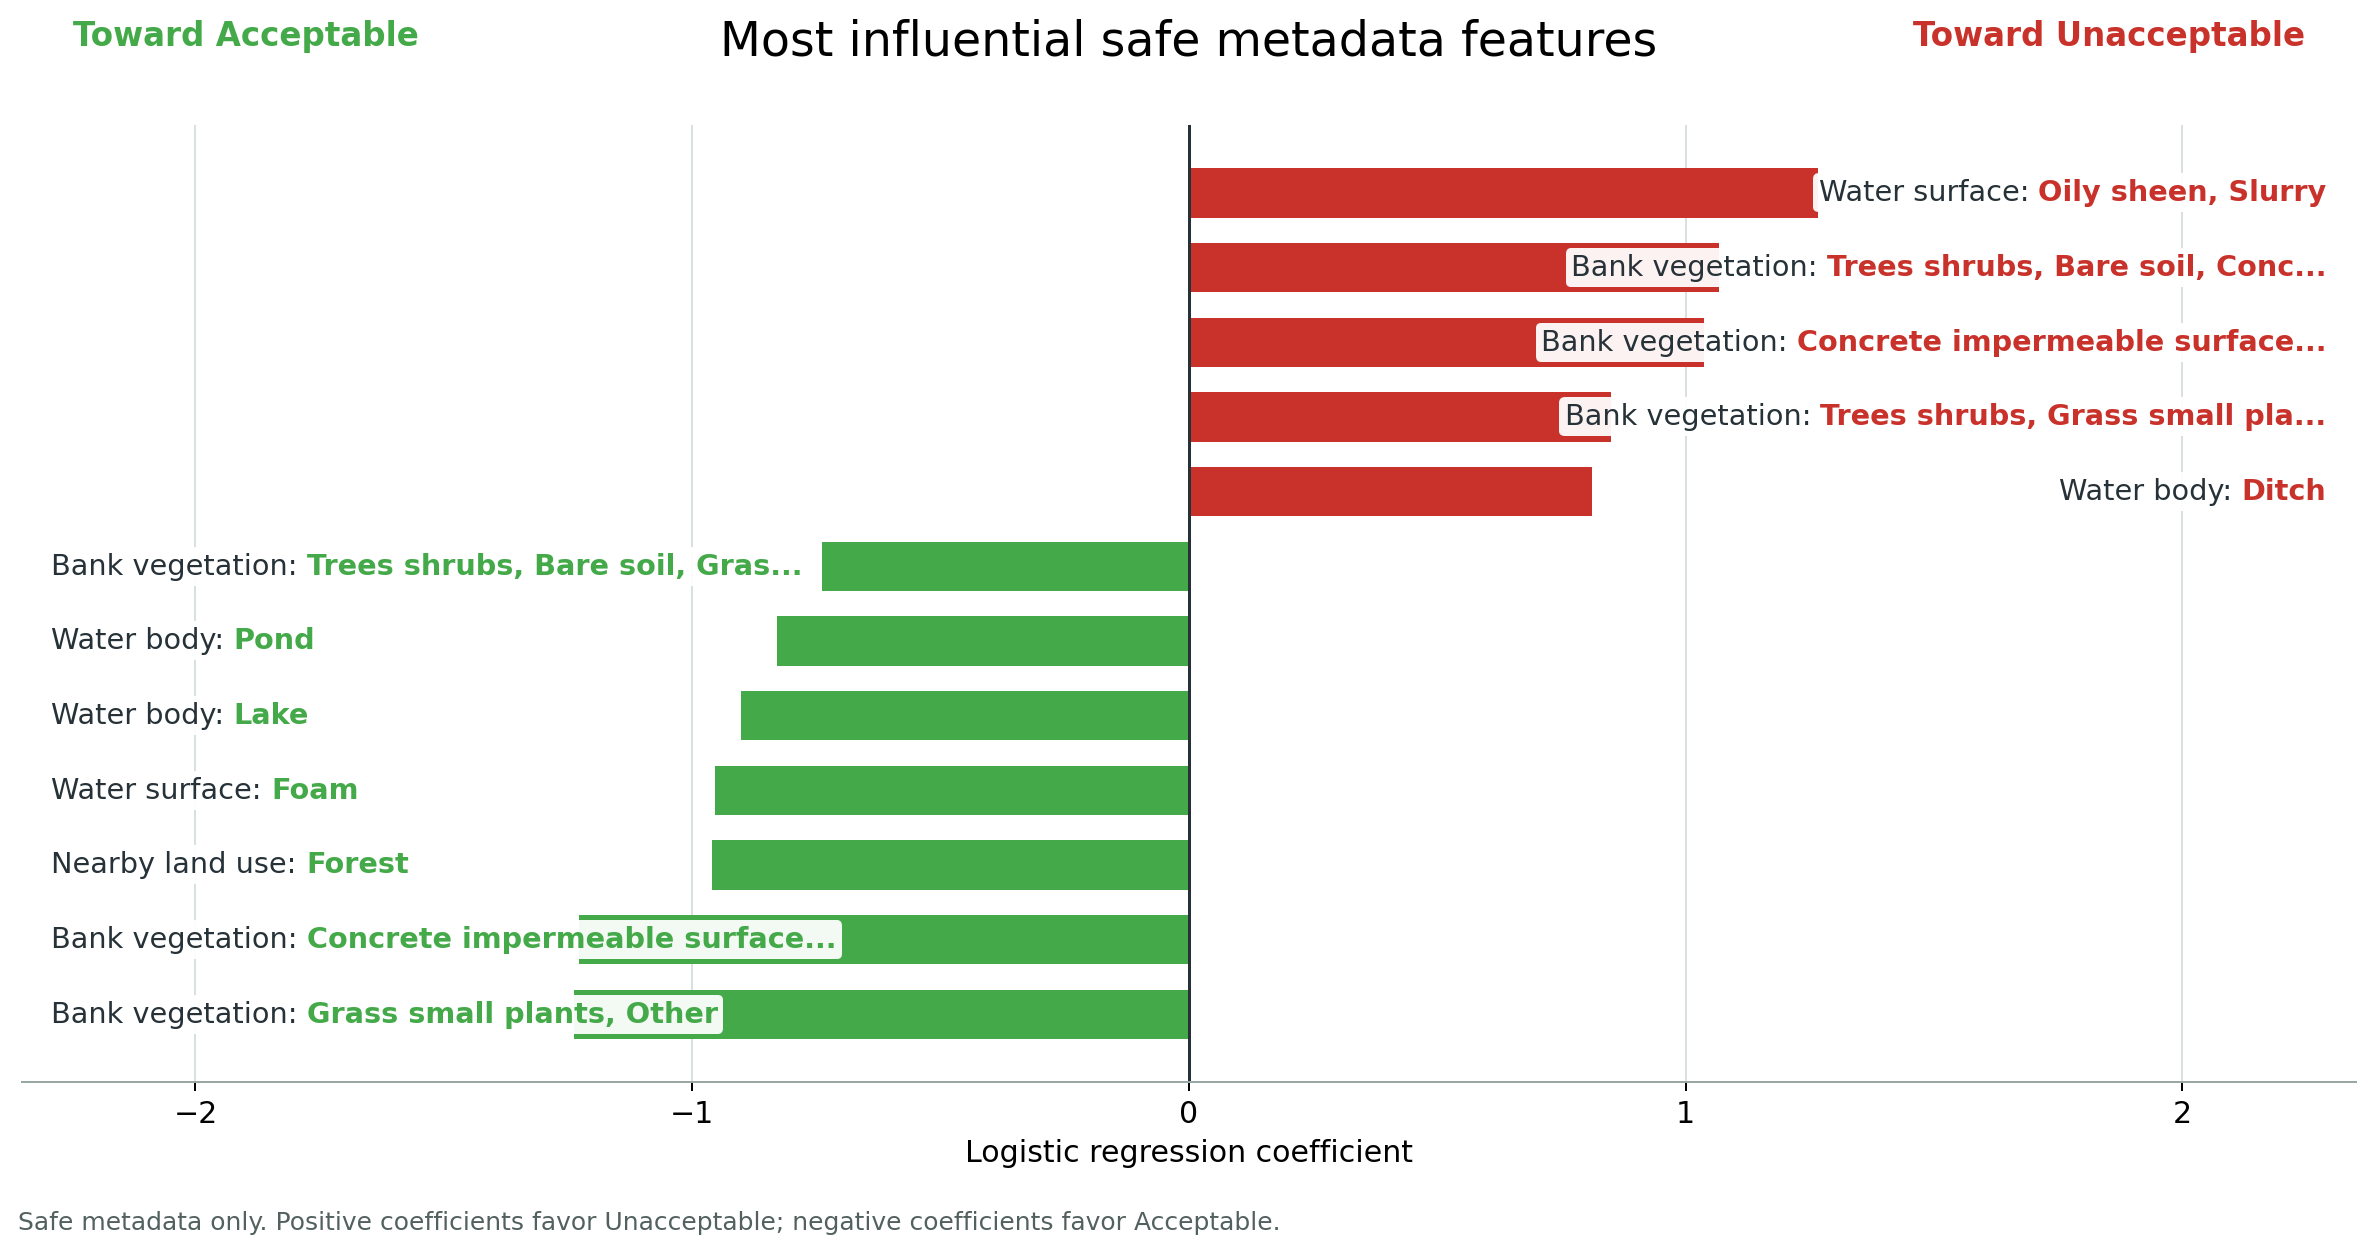

Wrote C:\Users\teaching\Downloads\earthwatch-cnn\outputs\metadata_feature_importance_top12.png
Wrote C:\Users\teaching\Downloads\earthwatch-cnn\outputs\metadata_feature_importance_top12.csv


In [9]:
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 19,
    'axes.labelsize': 12,
})

fig, ax = plt.subplots(figsize=(13.33, 7.5), dpi=180)
y_positions = list(range(len(plot_df)))
bar_colors = [UNACCEPTABLE_COLOR if value > 0 else ACCEPTABLE_COLOR for value in plot_df['coefficient']]

ax.barh(y_positions, plot_df['coefficient'], color=bar_colors, height=0.66)
ax.axvline(0, color=TEXT_COLOR, linewidth=1.2)
ax.set_xlim(-2.35, 2.35)
ax.set_yticks([])
ax.set_xlabel('Logistic regression coefficient')
ax.set_title('Most influential safe metadata features', pad=28)
ax.grid(axis='x', color=GRID_COLOR, linewidth=0.8)
ax.set_axisbelow(True)

fig.text(0.035, 0.902, 'Toward Acceptable', ha='left', va='center', color=ACCEPTABLE_COLOR, weight='bold', fontsize=13)
fig.text(0.965, 0.902, 'Toward Unacceptable', ha='right', va='center', color=UNACCEPTABLE_COLOR, weight='bold', fontsize=13)

for y, row in enumerate(plot_df.itertuples(index=False)):
    direction_color = UNACCEPTABLE_COLOR if row.coefficient > 0 else ACCEPTABLE_COLOR
    question = TextArea(row.question_short + ': ', textprops={'color': TEXT_COLOR, 'fontsize': 11.5})
    response = TextArea(row.response_short, textprops={'color': direction_color, 'fontsize': 11.5, 'weight': 'bold'})
    label = HPacker(children=[question, response], align='center', pad=0, sep=0)
    if row.coefficient < 0:
        x, alignment = -2.29, (0, 0.5)
    else:
        x, alignment = 2.29, (1, 0.5)
    ax.add_artist(AnnotationBbox(
        label,
        (x, y),
        xycoords='data',
        frameon=True,
        box_alignment=alignment,
        bboxprops={
            'facecolor': 'white',
            'edgecolor': 'none',
            'alpha': 0.94,
            'boxstyle': 'round,pad=0.18',
        },
    ))

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#9aa8a5')

fig.text(
    0.012,
    0.018,
    'Safe metadata only. Positive coefficients favor Unacceptable; negative coefficients favor Acceptable.',
    fontsize=10,
    color='#52615f',
)

plt.tight_layout(rect=(0, 0.04, 1, 0.94))
fig.savefig(png_path, bbox_inches='tight', facecolor='white')
plt.show()

print(f'Wrote {png_path}')
print(f'Wrote {csv_path}')


In [10]:
# Print all one-hot encoded fixed effects and their logistic-regression coefficients.
all_effects = coef_df.copy()
all_effects[['question', 'response']] = all_effects['feature'].apply(lambda value: pd.Series(split_feature(value)))
all_effects['question_short'] = all_effects['question'].map(shorten_question)
all_effects['response_short'] = all_effects['response'].map(lambda value: shorten_response(value, max_len=120))
all_effects['direction'] = all_effects['coefficient'].map(
    lambda value: 'Toward Unacceptable' if value > 0 else 'Toward Acceptable'
)
all_effects['abs_coefficient'] = all_effects['coefficient'].abs()
all_effects = all_effects.sort_values(['question_short', 'coefficient'], ascending=[True, False])

for question, group in all_effects.groupby('question_short', sort=False):
    print()
    print(f'## {question}')
    display(
        group[[
            'response_short',
            'coefficient',
            'abs_coefficient',
            'direction',
        ]].rename(columns={
            'response_short': 'response',
        }).reset_index(drop=True)
    )



## Bank vegetation


,response,coefficient,abs_coefficient,direction
0,"Trees shrubs, Bare soil, Concrete impermeable ...",1.066347,1.066347,Toward Unacceptable
1,"Concrete impermeable surface, Grass small plants",1.036491,1.036491,Toward Unacceptable
2,"Trees shrubs, Grass small plants, Concrete imp...",0.850303,0.850303,Toward Unacceptable
3,"Concrete impermeable surface, Trees shrubs, Gr...",0.549033,0.549033,Toward Unacceptable
4,"Concrete impermeable surface, Grass small plan...",0.543521,0.543521,Toward Unacceptable
...,...,...,...,...
59,"Trees shrubs, Bare soil, Other",-0.692657,0.692657,Toward Acceptable
60,Other,-0.708401,0.708401,Toward Acceptable
61,"Trees shrubs, Bare soil, Grass small plants, C...",-0.738035,0.738035,Toward Acceptable
62,"Concrete impermeable surface, Other",-1.227390,1.227390,Toward Acceptable



## Nearby land use


,response,coefficient,abs_coefficient,direction
0,Arable agricultural,0.706153,0.706153,Toward Unacceptable
1,Missing,0.675253,0.675253,Toward Unacceptable
2,Urban residential,0.303846,0.303846,Toward Unacceptable
3,Urban green space,0.203036,0.203036,Toward Unacceptable
4,Industrial commercial,0.114952,0.114952,Toward Unacceptable
5,Mixed agricultural,0.050399,0.050399,Toward Unacceptable
6,Grassland shrub,-0.071857,0.071857,Toward Acceptable
7,Other,-0.100056,0.100056,Toward Acceptable
8,Rural residential,-0.188906,0.188906,Toward Acceptable
9,Livestock,-0.591584,0.591584,Toward Acceptable



## Water body


,response,coefficient,abs_coefficient,direction
0,Ditch,0.810623,0.810623,Toward Unacceptable
1,River,0.534431,0.534431,Toward Unacceptable
2,Stream,0.473895,0.473895,Toward Unacceptable
3,Wetland,0.206666,0.206666,Toward Unacceptable
4,Other,0.102851,0.102851,Toward Unacceptable
5,Canal,-0.257217,0.257217,Toward Acceptable
6,Pond,-0.828511,0.828511,Toward Acceptable
7,Lake,-0.901194,0.901194,Toward Acceptable



## Water colour


,response,coefficient,abs_coefficient,direction
0,Green,0.520054,0.520054,Toward Unacceptable
1,White milky,0.262212,0.262212,Toward Unacceptable
2,Grey,0.231293,0.231293,Toward Unacceptable
3,Other,-0.068020,0.068020,Toward Acceptable
4,Colourless,-0.139120,0.139120,Toward Acceptable
5,Brown,-0.221488,0.221488,Toward Acceptable
6,Yellow,-0.443386,0.443386,Toward Acceptable



## Water surface


,response,coefficient,abs_coefficient,direction
0,"Oily sheen, Slurry",1.265813,1.265813,Toward Unacceptable
1,"Foam, Floating algae, Slurry",0.468335,0.468335,Toward Unacceptable
2,"Floating algae, Oily sheen",0.443629,0.443629,Toward Unacceptable
3,"Slurry, Floating algae",0.399265,0.399265,Toward Unacceptable
4,"None, Floating algae",0.345413,0.345413,Toward Unacceptable
5,"Slurry, Foam",0.315303,0.315303,Toward Unacceptable
6,"Floating algae, Oily sheen, Slurry",0.305229,0.305229,Toward Unacceptable
7,"Oily sheen, Floating algae",0.241505,0.241505,Toward Unacceptable
8,"Floating algae, Oily sheen, Foam",0.218679,0.218679,Toward Unacceptable
9,Slurry,0.174673,0.174673,Toward Unacceptable
